# Notebook 14 – XGBoost + LSTM Ensemble

Compares the two binary gentrification classifiers and evaluates whether combining them improves prediction.

**Models:**
- **XGBoost** (notebook 05) — socio-economic tabular features, CV macro-F1 ≈ 0.727
- **LSTM** (notebook 13) — CVR business-composition sequences, CV macro-F1 ≈ 0.523

**Prerequisites:** Run the proba-save cells added to notebooks 05 and 13 before running this notebook.
Those cells write:
- `results/models/xgb_proba_cph.csv` — XGBoost probabilities + split labels
- `results/models/lstm_proba_cph.csv` — LSTM probabilities + split labels

**Sections:**
1. Load & join probability files
2. Error overlap analysis — is combining worth it?
3. Hard voting ensemble (majority vote, XGBoost tie-break)
4. Soft voting ensemble (weighted probabilities + threshold sweep)
5. Comparison summary + verdict
6. Save ensemble predictions

## 1. Imports & Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, classification_report, f1_score,
    ConfusionMatrixDisplay, cohen_kappa_score
)

RESULTS_DIR = "../results/models"
FIGS_DIR    = "../results/figures"
os.makedirs(FIGS_DIR, exist_ok=True)

# CV macro-F1 scores used as soft-vote weights (from notebooks 05 and 13)
XGB_CV_F1  = 0.7275
LSTM_CV_F1 = 0.5230

print(f"XGBoost CV macro-F1 weight: {XGB_CV_F1}")
print(f"LSTM    CV macro-F1 weight: {LSTM_CV_F1}")

XGBoost CV macro-F1 weight: 0.7275
LSTM    CV macro-F1 weight: 0.523


## 2. Load Data

In [2]:
# Load probability files
xgb  = pd.read_csv(os.path.join(RESULTS_DIR, "xgb_proba_cph.csv"))
lstm = pd.read_csv(os.path.join(RESULTS_DIR, "lstm_proba_cph.csv"))

# Normalize cluster IDs
xgb['cluster_id']  = xgb['cluster_id'].astype(str).str.strip()
lstm['cluster_id'] = lstm['cluster_id'].astype(str).str.strip()

print(f"XGBoost rows:  {len(xgb)}  |  splits: {dict(xgb['split'].value_counts().sort_index())}")
print(f"LSTM rows:     {len(lstm)}  |  splits: {dict(lstm['split'].value_counts().sort_index())}")

# Rename to avoid collisions before merging
xgb_r  = xgb.rename(columns={
    'p_not_gentrified': 'xgb_p0',
    'p_gentrified':     'xgb_p1',
    'split':            'xgb_split',
    'actual_class':     'actual_class',
})
lstm_r = lstm.rename(columns={
    'p_not_gentrified': 'lstm_p0',
    'p_gentrified':     'lstm_p1',
    'split':            'lstm_split',
    'actual_class':     'actual_class_lstm',
})

# Inner join on cluster_id (only clusters covered by both models)
merged = xgb_r.merge(
    lstm_r[['cluster_id', 'lstm_p0', 'lstm_p1', 'lstm_split', 'actual_class_lstm']],
    on='cluster_id', how='inner'
)

print(f"\nInner-joined clusters: {len(merged)}")
print(f"Clusters only in XGBoost: {len(xgb) - len(merged)}")
print(f"Clusters only in LSTM:    {len(lstm) - len(merged)}")
print(f"\nMerged split distribution (XGBoost):")
print(merged['xgb_split'].value_counts().sort_index())

XGBoost rows:  2232  |  splits: {'test': np.int64(447), 'train': np.int64(1338), 'val': np.int64(447)}
LSTM rows:     2224  |  splits: {'test': np.int64(445), 'train': np.int64(1334), 'val': np.int64(445)}

Inner-joined clusters: 2224
Clusters only in XGBoost: 8
Clusters only in LSTM:    0

Merged split distribution (XGBoost):
xgb_split
test      445
train    1334
val       445
Name: count, dtype: int64


## 3. Error Overlap Analysis

Combining two classifiers only helps if their errors are **different** (complementary). This section measures:
- How many errors overlap (both models wrong on the same sample)
- Cohen's κ between the two models' predictions (κ near 0 = independent/complementary)

In [3]:
# Work on test split (ground truth = XGBoost actual_class, which comes from the same label source)
test = merged[merged['xgb_split'] == 'test'].copy()

# Hard predictions at default 0.5 threshold for diagnostic
test['xgb_pred']  = (test['xgb_p1']  >= 0.5).astype(int)
test['lstm_pred'] = (test['lstm_p1'] >= 0.5).astype(int)

y_true = test['actual_class']

xgb_wrong  = (test['xgb_pred']  != y_true)
lstm_wrong = (test['lstm_pred'] != y_true)
both_wrong = xgb_wrong & lstm_wrong
only_xgb   = xgb_wrong & ~lstm_wrong
only_lstm  = ~xgb_wrong & lstm_wrong

print("── Error Overlap Analysis (Test Set) ──")
print(f"Test samples:              {len(test)}")
print(f"XGBoost errors:            {xgb_wrong.sum()}  ({xgb_wrong.mean():.1%})")
print(f"LSTM errors:               {lstm_wrong.sum()}  ({lstm_wrong.mean():.1%})")
print(f"Both wrong (overlap):      {both_wrong.sum()}  ({both_wrong.sum()/xgb_wrong.sum():.1%} of XGB errors)")
print(f"Only XGBoost wrong:        {only_xgb.sum()}")
print(f"Only LSTM wrong:           {only_lstm.sum()}")

kappa = cohen_kappa_score(test['xgb_pred'], test['lstm_pred'])
agree_rate = (test['xgb_pred'] == test['lstm_pred']).mean()
print(f"\nPrediction agreement rate: {agree_rate:.1%}")
print(f"Cohen's κ (XGB vs LSTM):   {kappa:.4f}")
print("  → κ near 0 = complementary; κ near 1 = identical predictions")

if both_wrong.sum() / xgb_wrong.sum() > 0.70:
    print("\n⚠️  HIGH OVERLAP (>70%): Combining may not help much — models fail on similar samples.")
else:
    print("\n✅ LOW OVERLAP (<70%): Models make different errors — ensemble is likely beneficial.")

print("\n── XGBoost Test Report (default t=0.5) ──")
print(classification_report(y_true, test['xgb_pred'],
                             target_names=['Not Gentrified (0)', 'Gentrified (1)']))
print("── LSTM Test Report (default t=0.5) ──")
print(classification_report(y_true, test['lstm_pred'],
                             target_names=['Not Gentrified (0)', 'Gentrified (1)']))

── Error Overlap Analysis (Test Set) ──
Test samples:              445
XGBoost errors:            136  (30.6%)
LSTM errors:               180  (40.4%)
Both wrong (overlap):      69  (50.7% of XGB errors)
Only XGBoost wrong:        67
Only LSTM wrong:           111

Prediction agreement rate: 60.0%
Cohen's κ (XGB vs LSTM):   0.2019
  → κ near 0 = complementary; κ near 1 = identical predictions

✅ LOW OVERLAP (<70%): Models make different errors — ensemble is likely beneficial.

── XGBoost Test Report (default t=0.5) ──
                    precision    recall  f1-score   support

Not Gentrified (0)       0.62      0.75      0.68       191
    Gentrified (1)       0.78      0.65      0.71       254

          accuracy                           0.69       445
         macro avg       0.70      0.70      0.69       445
      weighted avg       0.71      0.69      0.70       445

── LSTM Test Report (default t=0.5) ──
                    precision    recall  f1-score   support

Not Gentrifie

## 4. Hard Voting Ensemble

Majority vote across both models. With 2 models, disagreement is resolved by defaulting to the better model (XGBoost).

── Hard Voting Ensemble (XGBoost tie-break) ──
                    precision    recall  f1-score   support

Not Gentrified (0)       0.62      0.75      0.68       191
    Gentrified (1)       0.78      0.65      0.71       254

          accuracy                           0.69       445
         macro avg       0.70      0.70      0.69       445
      weighted avg       0.71      0.69      0.70       445



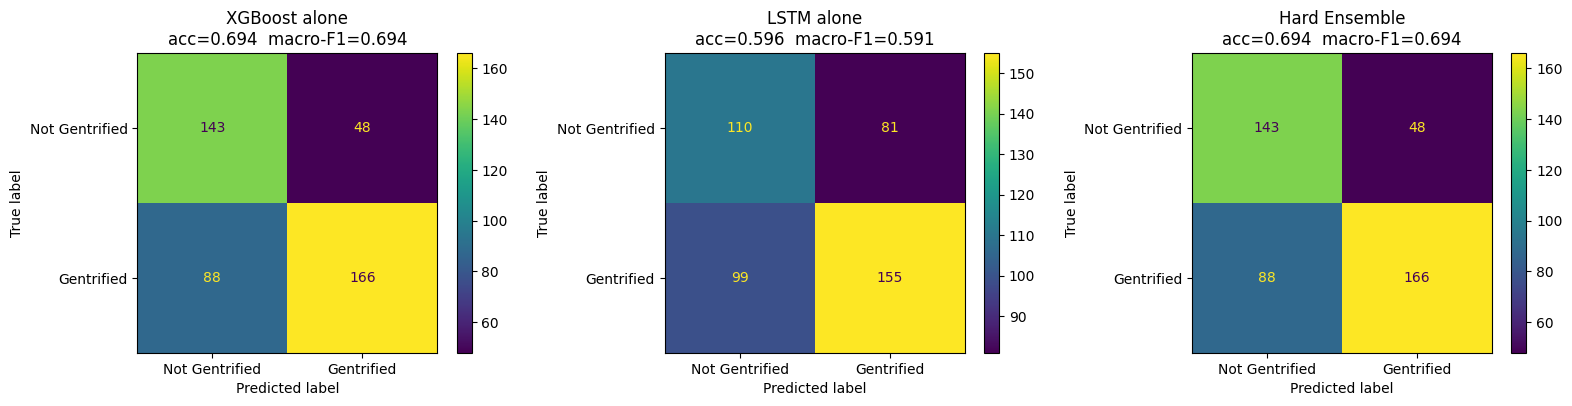

In [4]:
# Hard voting: agreement → that class; disagreement → XGBoost wins
test['hard_pred'] = np.where(
    test['xgb_pred'] == test['lstm_pred'],
    test['xgb_pred'],
    test['xgb_pred']   # tie-break: XGBoost
)

print("── Hard Voting Ensemble (XGBoost tie-break) ──")
print(classification_report(y_true, test['hard_pred'],
                             target_names=['Not Gentrified (0)', 'Gentrified (1)']))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (preds, title) in zip(axes, [
    (test['xgb_pred'],  'XGBoost alone'),
    (test['lstm_pred'], 'LSTM alone'),
    (test['hard_pred'], 'Hard Ensemble'),
]):
    ConfusionMatrixDisplay.from_predictions(
        y_true, preds, display_labels=['Not Gentrified', 'Gentrified'], ax=ax
    )
    acc = accuracy_score(y_true, preds)
    f1  = f1_score(y_true, preds, average='macro')
    ax.set_title(f'{title}\nacc={acc:.3f}  macro-F1={f1:.3f}')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'ensemble_hard_vote_confusion.jpg'), dpi=200)
plt.show()

## 5. Soft Voting Ensemble

Average the predicted probabilities from both models, weighted by their CV macro-F1 scores:

$$P_{\text{ensemble}}(y=1 \mid x) = w_{\text{XGB}} \cdot P_{\text{XGB}}(y=1) + w_{\text{LSTM}} \cdot P_{\text{LSTM}}(y=1)$$

Weights: $w_{\text{XGB}} = \frac{0.727}{0.727 + 0.523}$, $w_{\text{LSTM}} = \frac{0.523}{0.727 + 0.523}$

The decision threshold is tuned on the validation set.

Ensemble weights:  XGBoost=0.5818  LSTM=0.4182
Best threshold (val macro-F1=0.7325):  t=0.52


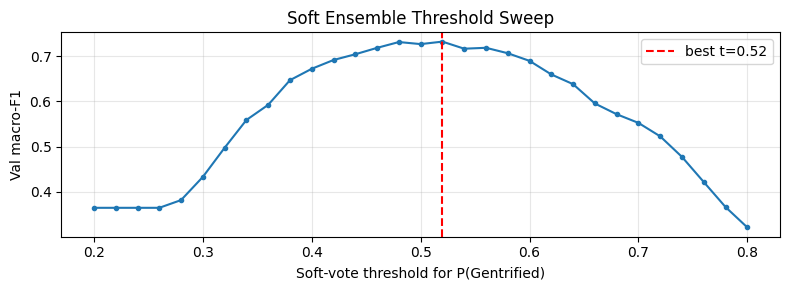

In [5]:
w_xgb  = XGB_CV_F1 / (XGB_CV_F1 + LSTM_CV_F1)
w_lstm = LSTM_CV_F1 / (XGB_CV_F1 + LSTM_CV_F1)
print(f"Ensemble weights:  XGBoost={w_xgb:.4f}  LSTM={w_lstm:.4f}")

# Tune threshold on validation set
val = merged[merged['xgb_split'] == 'val'].copy()
y_val = val['actual_class']
val['soft_p1'] = w_xgb * val['xgb_p1'] + w_lstm * val['lstm_p1']

thresholds = np.arange(0.20, 0.81, 0.02)
best_t_soft, best_f1_soft = 0.5, -1.0
f1_vals = []

for t in thresholds:
    preds_t = (val['soft_p1'] >= t).astype(int)
    f1_t = f1_score(y_val, preds_t, average='macro', zero_division=0)
    f1_vals.append(f1_t)
    if f1_t > best_f1_soft:
        best_f1_soft, best_t_soft = f1_t, float(t)

print(f"Best threshold (val macro-F1={best_f1_soft:.4f}):  t={best_t_soft:.2f}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(thresholds, f1_vals, marker='o', ms=3)
ax.axvline(best_t_soft, color='red', ls='--', label=f'best t={best_t_soft:.2f}')
ax.set_xlabel('Soft-vote threshold for P(Gentrified)')
ax.set_ylabel('Val macro-F1')
ax.set_title('Soft Ensemble Threshold Sweep')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'ensemble_threshold_sweep.jpg'), dpi=200)
plt.show()

In [6]:
# Evaluate soft ensemble on test set
test['soft_p1']   = w_xgb * test['xgb_p1'] + w_lstm * test['lstm_p1']
test['soft_pred'] = (test['soft_p1'] >= best_t_soft).astype(int)

print(f"── Soft Voting Ensemble (t={best_t_soft:.2f}) ──")
print(classification_report(y_true, test['soft_pred'],
                             target_names=['Not Gentrified (0)', 'Gentrified (1)']))

── Soft Voting Ensemble (t=0.52) ──
                    precision    recall  f1-score   support

Not Gentrified (0)       0.61      0.80      0.70       191
    Gentrified (1)       0.81      0.62      0.70       254

          accuracy                           0.70       445
         macro avg       0.71      0.71      0.70       445
      weighted avg       0.72      0.70      0.70       445



## 6. Comparison Summary & Verdict

── Model Comparison Summary (Test Set) ──
        Model  Accuracy  Macro-F1  F1 Not Gentrified  F1 Gentrified
      XGBoost    0.6944    0.6936             0.6777         0.7094
         LSTM    0.5955    0.5913             0.5500         0.6327
Hard Ensemble    0.6944    0.6936             0.6777         0.7094
Soft Ensemble    0.6989    0.6988             0.6955         0.7022


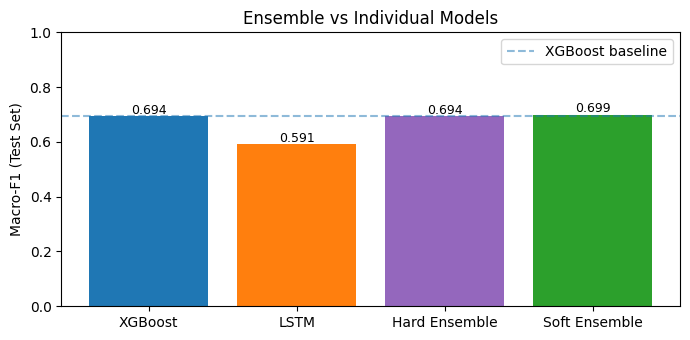


── Verdict ──
XGBoost alone:  macro-F1 = 0.6936
Best variant:   'Soft Ensemble'  macro-F1 = 0.6988  (Δ=+0.0052)

⚠️  No variant beats XGBoost by ≥2pp. Ensemble does not justify added complexity.
   Recommendation: use XGBoost alone for final predictions.


In [7]:
rows = []
for name, preds in [
    ('XGBoost',      test['xgb_pred']),
    ('LSTM',         test['lstm_pred']),
    ('Hard Ensemble',test['hard_pred']),
    ('Soft Ensemble',test['soft_pred']),
]:
    f1_per = f1_score(y_true, preds, average=None, zero_division=0)
    rows.append({
        'Model':               name,
        'Accuracy':            round(accuracy_score(y_true, preds), 4),
        'Macro-F1':            round(f1_score(y_true, preds, average='macro', zero_division=0), 4),
        'F1 Not Gentrified':   round(f1_per[0], 4) if len(f1_per) > 0 else None,
        'F1 Gentrified':       round(f1_per[1], 4) if len(f1_per) > 1 else None,
    })

summary = pd.DataFrame(rows)
print("── Model Comparison Summary (Test Set) ──")
print(summary.to_string(index=False))

# Visualise macro-F1 comparison
fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ['#1f77b4', '#ff7f0e', '#9467bd', '#2ca02c']
bars = ax.bar(summary['Model'], summary['Macro-F1'], color=colors)
ax.axhline(summary.loc[summary['Model'] == 'XGBoost', 'Macro-F1'].values[0],
           color='#1f77b4', ls='--', alpha=0.5, label='XGBoost baseline')
ax.set_ylabel('Macro-F1 (Test Set)')
ax.set_title('Ensemble vs Individual Models')
ax.set_ylim(0, 1)
for bar, val in zip(bars, summary['Macro-F1']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'ensemble_comparison.jpg'), dpi=200)
plt.show()

# Verdict
xgb_f1   = summary.loc[summary['Model'] == 'XGBoost', 'Macro-F1'].values[0]
best_row  = summary.loc[summary['Macro-F1'].idxmax()]
best_name = best_row['Model']
best_val  = best_row['Macro-F1']
gain      = best_val - xgb_f1

print(f"\n── Verdict ──")
print(f"XGBoost alone:  macro-F1 = {xgb_f1:.4f}")
print(f"Best variant:   '{best_name}'  macro-F1 = {best_val:.4f}  (Δ={gain:+.4f})")
if gain >= 0.02:
    print(f"\n✅ '{best_name}' beats XGBoost by ≥2pp — recommend using the ensemble.")
else:
    print(f"\n⚠️  No variant beats XGBoost by ≥2pp. Ensemble does not justify added complexity.")
    print(f"   Recommendation: use XGBoost alone for final predictions.")

## 7. Save Ensemble Predictions

In [8]:
# Compute predictions for all clusters in the joined dataset
full = merged.copy()
full['soft_p1_full'] = w_xgb * full['xgb_p1'] + w_lstm * full['lstm_p1']

full['xgb_pred']    = (full['xgb_p1']      >= 0.5).astype(int)
full['lstm_pred']   = (full['lstm_p1']     >= 0.5).astype(int)
full['hard_pred']   = np.where(
    full['xgb_pred'] == full['lstm_pred'],
    full['xgb_pred'],
    full['xgb_pred']  # XGBoost tie-break
)
full['soft_pred']   = (full['soft_p1_full'] >= best_t_soft).astype(int)

out = full[['cluster_id', 'xgb_pred', 'lstm_pred', 'hard_pred', 'soft_pred']].copy()
out_path = os.path.join(RESULTS_DIR, 'ensemble_predictions.csv')
out.to_csv(out_path, index=False)
print(f"Saved: {out_path}  (rows={len(out)})")
print("\nPrediction distribution per model:")
for col in ['xgb_pred', 'lstm_pred', 'hard_pred', 'soft_pred']:
    print(f"  {col:15s}: {dict(out[col].value_counts().sort_index())}")
print("\n  0 = Not Gentrified,  1 = Gentrified")

Saved: ../results/models\ensemble_predictions.csv  (rows=2224)

Prediction distribution per model:
  xgb_pred       : {0: np.int64(1054), 1: np.int64(1170)}
  lstm_pred      : {0: np.int64(1005), 1: np.int64(1219)}
  hard_pred      : {0: np.int64(1054), 1: np.int64(1170)}
  soft_pred      : {0: np.int64(1105), 1: np.int64(1119)}

  0 = Not Gentrified,  1 = Gentrified


## 8. Future Predictions: 2025, 2030, 2035

A **probability-drift projection** is applied to both models' 2020 probabilities, then the ensemble combines them.

**Mechanism — drift $p_1$ (Gentrified) upward over time:**

$$p_1^{(t)} = 1 - (1 - p_1^{(2020)}) \cdot \delta^{t/5}, \quad \delta = 0.95$$

Since $\delta < 1$, the "stability residual" $(1 - p_1)$ shrinks each step, so $p_1$ grows — modelling increasing gentrification pressure over time. Applied independently to XGBoost and LSTM probabilities, then soft-vote weighted and thresholded at `best_t_soft`.

> **Note on LSTM future projections:** The LSTM was trained on CVR business data — we have no future CVR sequences to run it on directly. The drift projection is an approximation assuming the same directional trend. It is a modelling assumption, not a data-driven forecast.

── Ensemble Future Predictions (gentrification pressure increasing) ──
Weights: XGBoost=0.5818  LSTM=0.4182
Threshold: 0.52  |  TRANSITION_FACTOR=0.95

2025  (t=5y, retention=0.950):  {0: 1031, 1: 1193}  (Not Gentrified=46.4%)
  Saved: ../results/models\ensemble_future_2025.csv
2030  (t=10y, retention=0.902):  {0: 944, 1: 1280}  (Not Gentrified=42.4%)
  Saved: ../results/models\ensemble_future_2030.csv
2035  (t=15y, retention=0.857):  {0: 856, 1: 1368}  (Not Gentrified=38.5%)
  Saved: ../results/models\ensemble_future_2035.csv


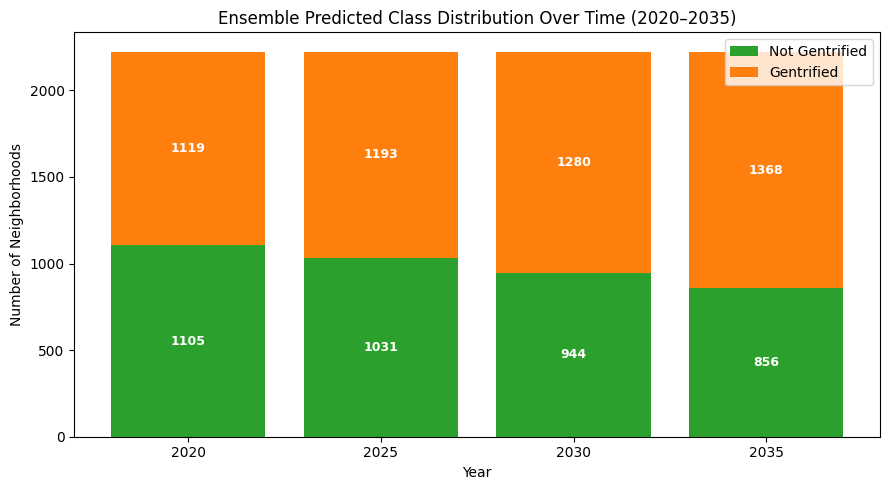


Saved: ../results/figures\ensemble_timeline.jpg

Class counts per year:
prediction  Not Gentrified  Gentrified
year                                  
2020                  1105        1119
2025                  1031        1193
2030                   944        1280
2035                   856        1368


In [12]:

# ── Probability-drift future projection (ensemble) ────────────────────────────
# Drift P(Gentrified) UPWARD over time — models increasing gentrification pressure.
# TRANSITION_FACTOR = 0.95: each 5-year step, 5% of the remaining "stability
# residual" (1 - p1) shrinks, pushing p1 higher.
TRANSITION_FACTOR = 0.95
FUTURE_HORIZONS   = {2025: 5, 2030: 10, 2035: 15}

# 2020 baseline probabilities for all clusters in the ensemble
base = full[['cluster_id', 'xgb_p0', 'xgb_p1', 'lstm_p0', 'lstm_p1']].copy()

future_dfs = []
print("── Ensemble Future Predictions (gentrification pressure increasing) ──")
print(f"Weights: XGBoost={w_xgb:.4f}  LSTM={w_lstm:.4f}")
print(f"Threshold: {best_t_soft:.2f}  |  TRANSITION_FACTOR={TRANSITION_FACTOR}\n")

for year, t_ahead in FUTURE_HORIZONS.items():
    retention = TRANSITION_FACTOR ** (t_ahead / 5)

    # Drift each model's P(Gentrified) upward
    xgb_p1_new  = 1.0 - (1.0 - base['xgb_p1'].values) * retention
    xgb_p0_new  = 1.0 - xgb_p1_new

    lstm_p1_new = 1.0 - (1.0 - base['lstm_p1'].values) * retention
    lstm_p0_new = 1.0 - lstm_p1_new

    # Soft ensemble on drifted probabilities
    ens_p1_new = w_xgb * xgb_p1_new + w_lstm * lstm_p1_new
    preds      = (ens_p1_new >= best_t_soft).astype(int)

    dist = {0: int((preds == 0).sum()), 1: int((preds == 1).sum())}
    print(f"{year}  (t={t_ahead}y, retention={retention:.3f}):  {dist}  "
          f"(Not Gentrified={dist[0]/len(preds):.1%})")

    df_fut = pd.DataFrame({
        'cluster_id':        base['cluster_id'].values,
        'prediction':        preds,
        'xgb_p_gentrified':  xgb_p1_new,
        'lstm_p_gentrified': lstm_p1_new,
        'ens_p_gentrified':  ens_p1_new,
        'year':              year,
    })
    out_p = os.path.join(RESULTS_DIR, f'ensemble_future_{year}.csv')
    df_fut[['cluster_id', 'prediction']].to_csv(out_p, index=False)
    print(f"  Saved: {out_p}")
    future_dfs.append(df_fut)

# ── Timeline stacked bar chart ─────────────────────────────────────────────────
df_2020 = full[['cluster_id', 'soft_pred']].copy().rename(columns={'soft_pred': 'prediction'})
df_2020['year'] = 2020

timeline = pd.concat([df_2020] + [d[['cluster_id', 'prediction', 'year']] for d in future_dfs],
                     ignore_index=True)
counts = (
    timeline.groupby(['year', 'prediction']).size()
    .unstack(fill_value=0).reindex(columns=[0, 1], fill_value=0)
)

class_labels = {0: 'Not Gentrified', 1: 'Gentrified'}
clr          = {0: '#2ca02c', 1: '#ff7f0e'}

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(counts))
x = np.arange(len(counts))
for cls in [0, 1]:
    vals = counts[cls].values
    ax.bar(x, vals, bottom=bottom, label=class_labels[cls], color=clr[cls])
    for xi, v, b in zip(x, vals, bottom):
        ax.text(xi, b + v / 2, str(v), ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(counts.index.astype(str))
ax.set_xlabel('Year')
ax.set_ylabel('Number of Neighborhoods')
ax.set_title('Ensemble Predicted Class Distribution Over Time (2020–2035)')
ax.legend(loc='upper right')
plt.tight_layout()

fig_path = os.path.join(FIGS_DIR, 'ensemble_timeline.jpg')
fig.savefig(fig_path, dpi=200)
plt.show()
print(f"\nSaved: {fig_path}")
print("\nClass counts per year:")
print(counts.rename(columns=class_labels).to_string())
